Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

Download nltk resources

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Load the Dataset

In [5]:
fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
print("Fake shape:", fake.shape)
print("True shape:", true.shape)

Fake shape: (23481, 4)
True shape: (21417, 4)


Add Target Column

In [8]:
fake["label"] = 0
true["label"] = 1

Combine Both Datasets

In [9]:
df = pd.concat([fake, true], axis=0)

df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
10878,MINORITY TRUMP SUPPORTERS Thrown Out Of Maxine...,The video below begins with a Hispanic man tel...,politics,"May 15, 2017",0
21389,"Trump must be respected as U.S. president, say...",BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"August 23, 2017",1
91,That Time Trump Mocked Marco Rubio For Drinki...,"While on the campaign trail, candidate Donald ...",News,"November 15, 2017",0
9553,U.S. probes Trump's former butler for urging O...,NEW YORK (Reuters) - The U.S. Secret Service i...,politicsNews,"May 12, 2016",1
159,Mulvaney says U.S. tax bill votes could be Tue...,WASHINGTON (Reuters) - White House budget dire...,politicsNews,"December 14, 2017",1


In [10]:
df.shape

(44898, 5)

Check Missing Values

In [11]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


Data Visualization

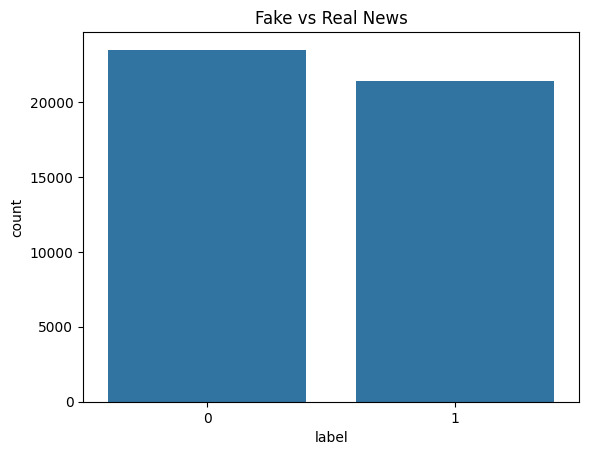

In [12]:
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News")
plt.show()

# Text Cleaning (NLP Preprocessing)

In [13]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["text"] = df["text"].apply(clean_text)

Convert Text to Numerical Features (TF-IDF)

In [14]:
# Import required library
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",   # Remove common English words like 'the', 'is'
    max_df=0.7,             # Ignore words appearing in more than 70% of documents
    ngram_range=(1, 2)      # Use both single words (unigrams) and two-word combinations (bigrams)
)

# Convert text data into numerical TF-IDF features
X = tfidf_vectorizer.fit_transform(df["text"])

# Target variable (Fake = 0, Real = 1 or based on your dataset)
y = df["label"]

Train Test Split

# Passive Aggressive Classifier

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

tfidf_train = vectorizer.fit_transform(X_train)
tfidf_test = vectorizer.transform(X_test)

model = PassiveAggressiveClassifier(max_iter=1000)
model.fit(tfidf_train, y_train)


PassiveAggressiveClassifier()

In [16]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

y_pred = model.predict(tfidf_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

print("Passive Aggressive Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4791
           1       0.99      0.99      0.99      4189

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Passive Aggressive Accuracy: 0.9934298440979955


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9934298440979955


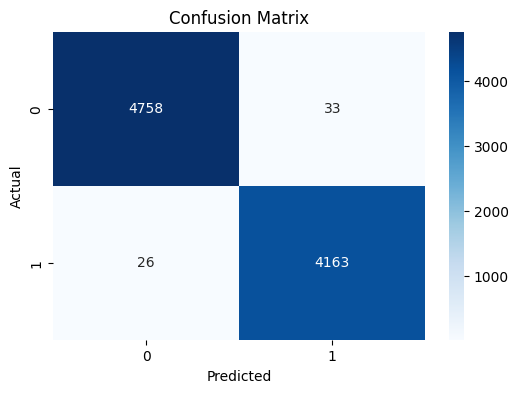

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Train Machine Learning Model

# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
X = df['text']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

tfidf_train = vectorizer.fit_transform(X_train)
tfidf_test = vectorizer.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(tfidf_train, y_train)

# Predict
y_pred = model.predict(tfidf_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9837416481069042

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4791
           1       0.98      0.98      0.98      4189

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



Confusion Matrix Visualization

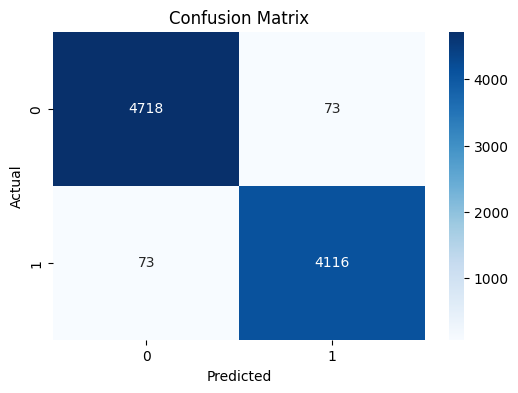

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Naive Bayes

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X = df['text']
y = df['label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF
naive_bayes_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
tfidf_train = naive_bayes_vectorizer.fit_transform(X_train)
tfidf_test = naive_bayes_vectorizer.transform(X_test)

# Naive Bayes model
model = MultinomialNB()
model.fit(tfidf_train, y_train)

# Prediction
y_pred = model.predict(tfidf_test)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))

Naive Bayes Accuracy: 0.9345211581291759


# Accuracy Graph

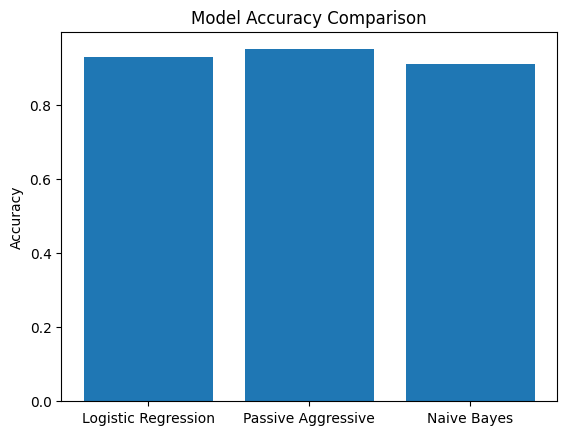

In [23]:
models = ["Logistic Regression", "Passive Aggressive", "Naive Bayes"]
scores = [0.93, 0.95, 0.91]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

Word Cloud Visualization

In [24]:
!pip install wordcloud

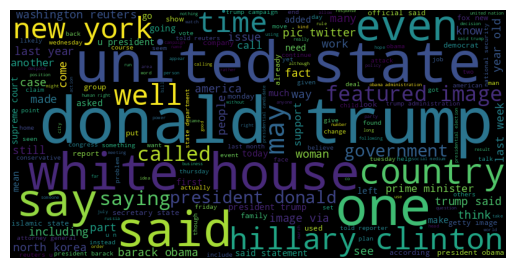

In [25]:
from wordcloud import WordCloud

text = " ".join(df["text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

Create Word Cloud for Fake News

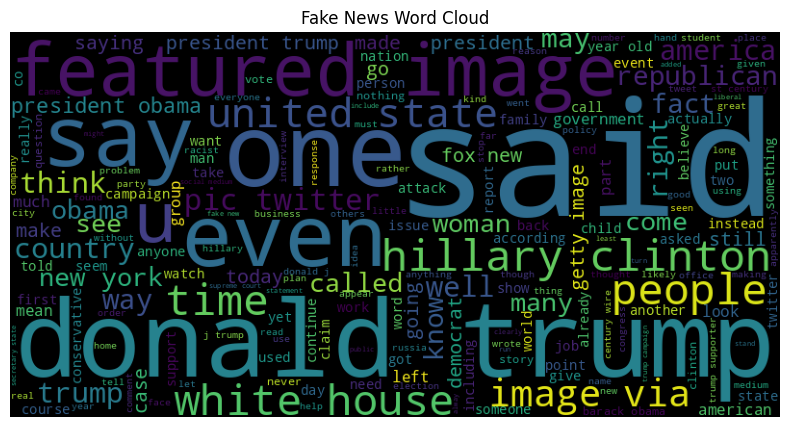

In [26]:
fake_words = " ".join(df[df["label"] == 0]["text"])

fake_wordcloud = WordCloud(width=800, height=400,
                           background_color="black").generate(fake_words)

plt.figure(figsize=(10,5))
plt.imshow(fake_wordcloud)
plt.axis("off")
plt.title("Fake News Word Cloud")
plt.show()

Create Word Cloud for Real News

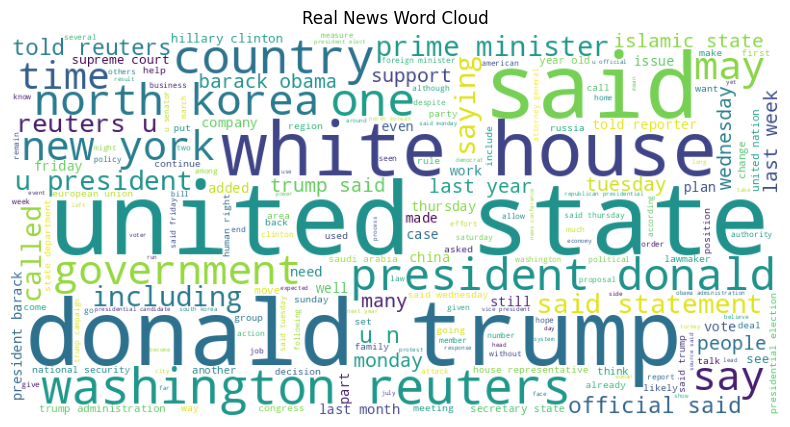

In [27]:
true_words = " ".join(df[df["label"] == 1]["text"])

true_wordcloud = WordCloud(width=800, height=400,
                           background_color="white").generate(true_words)

plt.figure(figsize=(10,5))
plt.imshow(true_wordcloud)
plt.axis("off")
plt.title("Real News Word Cloud")
plt.show()

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

fake_text = df[df["label"] == 0]["text"]

real_text = df[df["label"] == 1]["text"]

In [30]:
vectorizer = CountVectorizer(stop_words="english")

fake_matrix = vectorizer.fit_transform(fake_text)

fake_words = fake_matrix.toarray().sum(axis=0)

fake_freq = dict(zip(vectorizer.get_feature_names_out(), fake_words))

In [31]:
import pandas as pd

fake_df = pd.DataFrame(fake_freq.items(), columns=["word","count"])

fake_df = fake_df.sort_values(by="count", ascending=False).head(20)

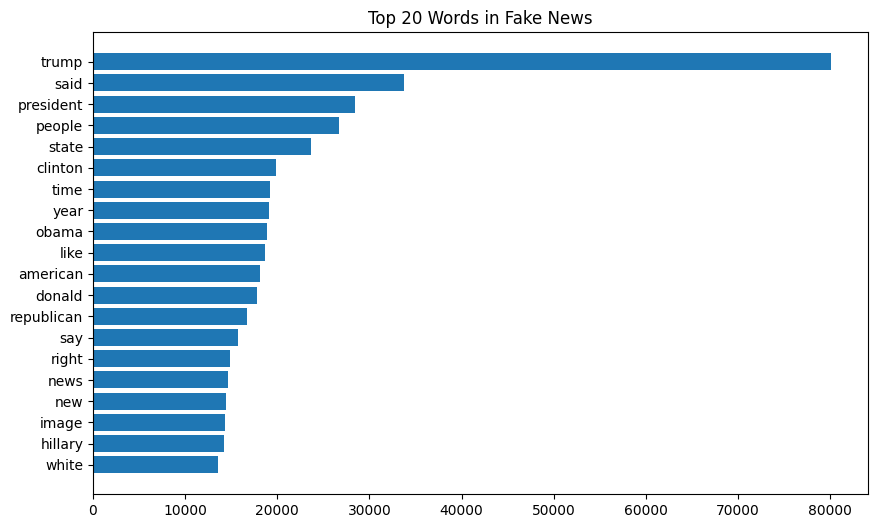

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(fake_df["word"], fake_df["count"])

plt.title("Top 20 Words in Fake News")

plt.gca().invert_yaxis()

plt.show()

In [33]:
vectorizer = CountVectorizer(stop_words="english")

real_matrix = vectorizer.fit_transform(real_text)

real_words = real_matrix.toarray().sum(axis=0)

real_freq = dict(zip(vectorizer.get_feature_names_out(), real_words))

In [34]:
real_df = pd.DataFrame(real_freq.items(), columns=["word","count"])

real_df = real_df.sort_values(by="count", ascending=False).head(20)

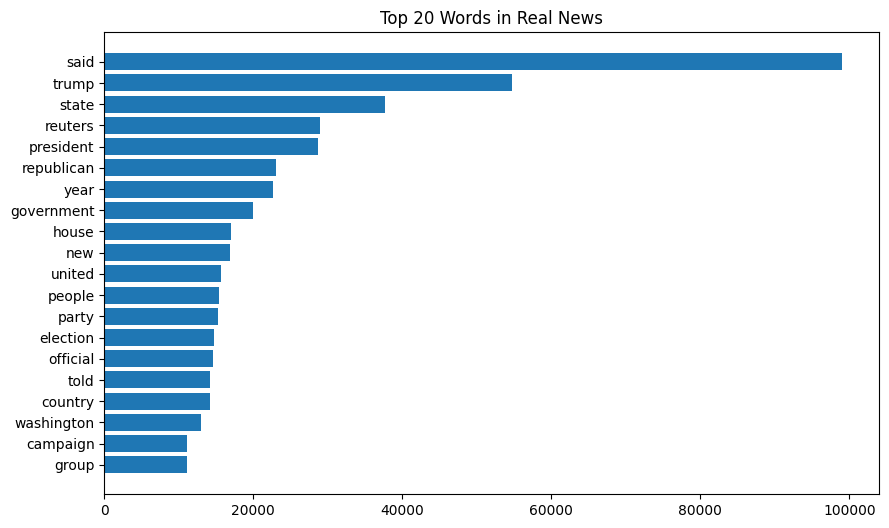

In [35]:
plt.figure(figsize=(10,6))

plt.barh(real_df["word"], real_df["count"])

plt.title("Top 20 Words in Real News")

plt.gca().invert_yaxis()

plt.show()

Test Custom News Prediction

In [39]:
def predict_news(news):

    vectorizer = TfidfVectorizer()
    news_vec = tfidf_vectorizer.transform(news)
    prediction = model.predict(news_vec)

    if prediction[0] == "REAL":
        print("Real News")
    else:
        print("Fake News")

In [49]:
news = ["Breaking news government announces new policy"]

# Convert text to TF-IDF using the vectorizer from the Naive Bayes model
vector = naive_bayes_vectorizer.transform(news)

# Predict
prediction = model.predict(vector)

# Output
# The output `prediction[0]` will be an integer (0 for Fake, 1 for Real)
# You can interpret it directly or use a conditional statement for clarity.

if prediction[0] == "Real":
    print("Prediction: Real News")
else:
    print("Prediction: Fake News")

Prediction: Fake News


In [50]:
news = ["Government officials said new economic policy announced"]

vector = naive_bayes_vectorizer.transform(news)

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Real News


In [51]:
news = ["Shocking secret doctors hide from you"]

vector = naive_bayes_vectorizer.transform(news)

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


In [52]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 110.3 MB/s eta 0:00:00


Save Your Trained Model

In [53]:
import pickle
pickle.dump(model, open("model.pkl","wb"))
pickle.dump(tfidf_vectorizer, open("vectorizer.pkl","wb"))


In [54]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>